In [2]:
from google.colab import files
upload = files.upload()

Saving insurance.csv to insurance.csv


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


In [4]:
df = pd.read_csv("insurance.csv")

In [5]:
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [6]:
df.tail()

,age,sex,bmi,children,smoker,region,charges
1333,50,male,30.97,3,no,northwest,10600.5483
1334,18,female,31.92,0,no,northeast,2205.9808
1335,18,female,36.85,0,no,southeast,1629.8335
1336,21,female,25.80,0,no,southwest,2007.9450
1337,61,female,29.07,0,yes,northwest,29141.3603


In [7]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB
None


In [8]:
df.describe()

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


In [9]:
df.isnull().sum()

,0
age,0
sex,0
bmi,0
children,0
smoker,0
region,0
charges,0


In [10]:
print(df.duplicated().sum())

1


In [11]:
df.drop_duplicates(inplace=True)
print(df.duplicated().sum())

0


In [12]:
X = df.drop("charges",axis=1)
X = pd.get_dummies(X, columns=['sex', 'smoker', 'region'], drop_first=True)
y = df["charges"]

In [14]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)

In [15]:
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(1069, 8)
(268, 8)
(1069,)
(268,)


In [19]:
model = LinearRegression()
print("\nLinear Regression is created")


Linear Regression is created


In [20]:
model.fit(X_train,y_train)
print("\nModel training is completed")


Model training is completed


In [21]:
print("\nIntercept")
print(model.intercept_)
print("\nCofficients")

coefficients = pd.DataFrame({
    "Feature":X.columns,
    "coefficients":model.coef_[0]
  })
print(coefficients)


Intercept
-11092.65229594595

Cofficients
            Feature  coefficients
0               age     248.21072
1               bmi     248.21072
2          children     248.21072
3          sex_male     248.21072
4        smoker_yes     248.21072
5  region_northwest     248.21072
6  region_southeast     248.21072
7  region_southwest     248.21072


In [22]:
prediction = model.predict(X_test)
print("\nPrediction Completed")


Prediction Completed


In [23]:
comparison = pd.DataFrame({
    "Actual Profit":y_test.values.flatten(),
    "Predicted Profit":prediction.flatten()
})
print("\nActual vs Predicted")
print(comparison.head(20))


Actual vs Predicted
    Actual Profit  Predicted Profit
0      8688.85885       8143.693884
1      5708.86700       5737.115683
2     11436.73815      14369.314876
3     38746.35510      31745.513636
4      4463.20510       8962.386657
5      9304.70190      13149.722353
6     38511.62830      30446.760679
7      2150.46900       1453.288813
8      7345.72660      10633.018402
9     10264.44210      11318.943794
10    13415.03810      10377.853573
11    24393.62240      33118.437664
12    37607.52770      31077.252738
13    13063.88300      17411.925288
14    24915.04626      10801.674283
15     8027.96800       9528.899642
16     1980.07000       4161.037843
17    38709.17600      31731.537266
18     3484.33100       3219.388753
19     3947.41310       5229.924601


In [24]:
mae = mean_absolute_error(y_test, prediction)

mse = mean_squared_error(y_test, prediction)

rmse = np.sqrt(mse)

r2 = r2_score(y_test, prediction)

print("\nMODEL PERFORMANCE")
print("-"*40)

print("Mean Absolute Error :", mae)

print("Mean Squared Error :", mse)

print("Root Mean Squared Error :", rmse)

print("R2 Score :", r2)



MODEL PERFORMANCE
----------------------------------------
Mean Absolute Error : 4177.045561036319
Mean Squared Error : 35478020.67523561
Root Mean Squared Error : 5956.342894363588
R2 Score : 0.8069287081198011


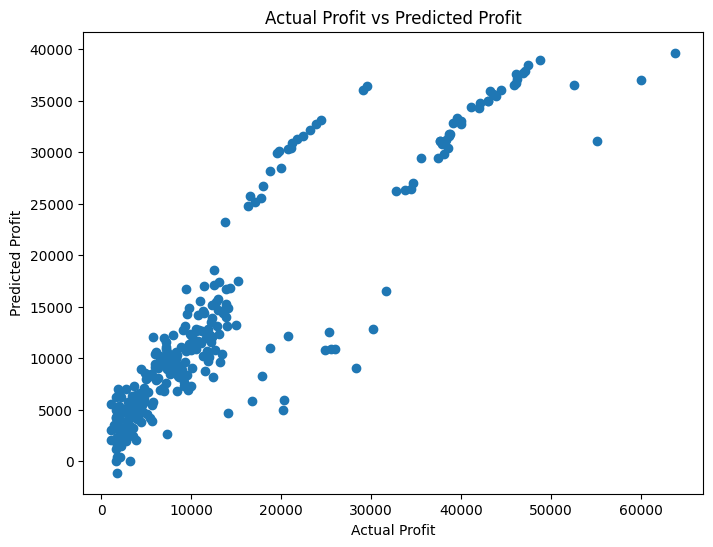

In [25]:
plt.figure(figsize=(8,6))

plt.scatter(
    y_test,
    prediction
)

plt.xlabel("Actual Profit")

plt.ylabel("Predicted Profit")

plt.title("Actual Profit vs Predicted Profit")

plt.grid(False)

plt.show()

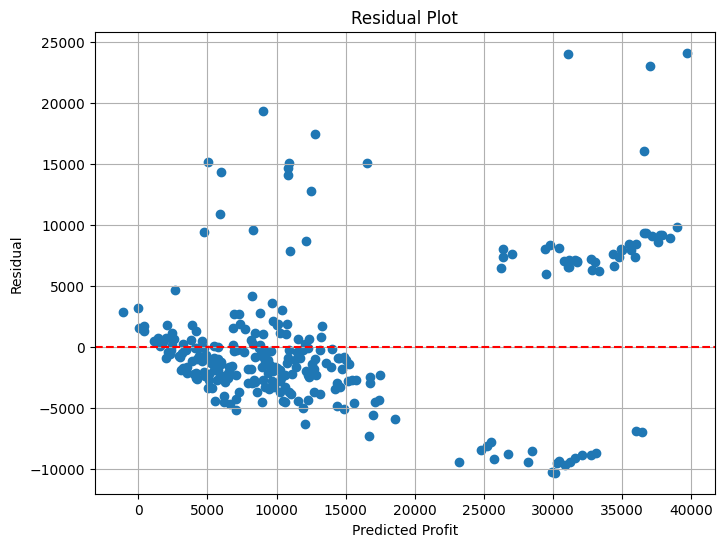

In [26]:
residual = y_test - prediction

plt.figure(figsize=(8,6))

plt.scatter(
    prediction,
    residual
)

plt.axhline(
    y=0,
    color='red',
    linestyle='--'
)

plt.xlabel("Predicted Profit")

plt.ylabel("Residual")

plt.title("Residual Plot")

plt.grid(True)

plt.show()


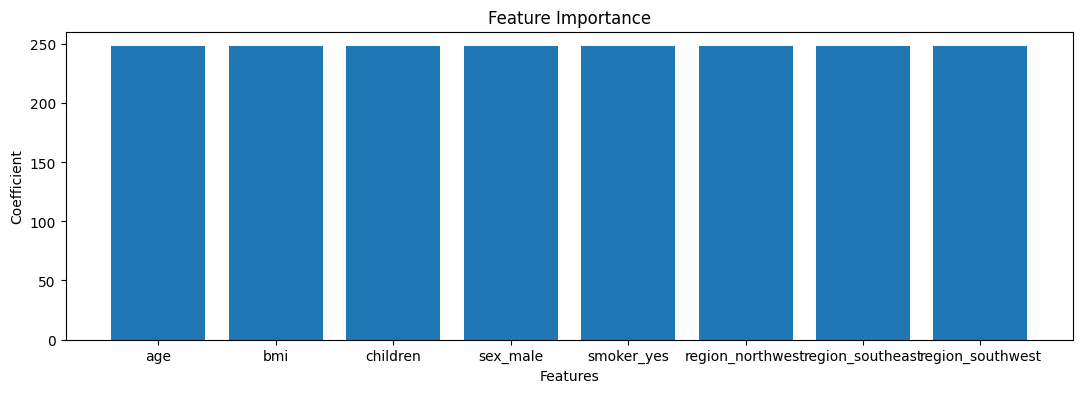

In [35]:
plt.figure(figsize=(13,4))

plt.bar(
    coefficients["Feature"],
    coefficients["coefficients"]
)

plt.title("Feature Importance")

plt.xlabel("Features")

plt.ylabel("Coefficient")

plt.show()